# Random vs UCB Stochastic Approximation

Compare `StochasticApproximation` (pure random search) against `StochasticApproximationUCBDynamic` (UCB over an adaptive binary partition) on a list of trained `ReLUNet`s.

Pipeline per architecture:
1. Train the network on a synthetic regression target.
2. Run both methods across `N_SEEDS` repeats with the full `COMPARE_ITERS` budget — no early stop, no ground-truth reference.
3. Plot mean ± std convergence bands vs iterations and vs wall-clock time.

In [1]:
import sys, time
sys.path.append('..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from relu_nets import ReLUNet
from hyperbox import Hyperbox
from other_methods import StochasticApproximation, StochasticApproximationUCBDynamic

## Config — edit this cell

In [2]:
ARCHITECTURES = [
    [2, 32, 32, 1],
    [3, 32, 32, 32, 1],
    [4, 32, 32, 32, 1],
    [4, 64, 64, 64, 64, 1],
    [8, 32, 32, 32, 1],
    [8, 64, 64, 64, 64, 1],
]

DOMAIN_RADIUS = 1.0
PRIMAL_NORM   = 'linf'

TRAIN_SAMPLES = 4096
TRAIN_EPOCHS  = 1500
TRAIN_LR      = 1e-3
TRAIN_SEED    = 0

COMPARE_ITERS = 500_000
N_SEEDS       = 5
SEEDS         = list(range(N_SEEDS))

UCB_C         = 15
UCB_PARTITION = 2

## Helpers

Two thin subclasses mirror the original solver loops (`other_methods/stochastic_approximation.py:30-60`, `other_methods/stochastic_approximation_ucb_dynamic.py:308-345`) and add per-iteration history (best-so-far value + wall time).

In [3]:
def train_network(arch, n_samples, epochs, lr, domain_radius, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    net = ReLUNet(arch)
    d = arch[0]
    X = (torch.rand(n_samples, d) * 2 - 1) * domain_radius
    y = torch.sin(X.norm(dim=1, keepdim=True)) + 0.1 * X[:, :1]
    opt  = torch.optim.Adam(net.parameters(), lr=lr)
    loss = torch.nn.MSELoss()
    for _ in range(epochs):
        opt.zero_grad()
        loss(net(X), y).backward()
        opt.step()
    return net


class RandomSAHist(StochasticApproximation):
    def compute(self, max_iter=10000, **_):
        self.history_value = np.empty(max_iter, dtype=np.float64)
        self.history_time  = np.empty(max_iter, dtype=np.float64)
        self.iteration_count = 0
        random_pts = self.domain.random_point(num_points=max_iter, requires_grad=False)
        random_pts = random_pts.to(self.DEVICE).detach().requires_grad_(True)
        t0 = time.perf_counter()
        for it in range(max_iter):
            fx = self.f(random_pts[it])
            if self.value < fx:
                self.value = torch.maximum(self.value, fx)
            self.iteration_count += 1
            self.history_value[it] = float(self.value)
            self.history_time[it]  = time.perf_counter() - t0
        self.compute_time = float(self.history_time[-1])
        return self.value.cpu().detach().numpy().squeeze()


class UCBSAHist(StochasticApproximationUCBDynamic):
    def compute(self, max_iter=1000, **_):
        self.history_value = np.empty(max_iter, dtype=np.float64)
        self.history_time  = np.empty(max_iter, dtype=np.float64)
        self.iteration_count = 0
        next_partition = self.partition_step
        step_mul = self.partition_step
        self.space.max_iter = max_iter
        t0 = time.perf_counter()
        for it in range(max_iter):
            if it == next_partition:
                self.space.increment()
                next_partition = next_partition * step_mul
            reg = self.space.choose_region()
            x = reg.get_random_points(1)
            fx = self.f(x)
            fx_scalar = float(fx.detach().cpu().item())
            x_np = x.detach().cpu().numpy().reshape(-1)[:self.space.dimension]
            self.space.add_evaluation(x_np, fx_scalar)
            if self.value < fx:
                self.value = torch.maximum(self.value, fx)
                self.answer_coords = x.detach().cpu().numpy()
            self.iteration_count += 1
            self.history_value[it] = float(self.value)
            self.history_time[it]  = time.perf_counter() - t0
        self.compute_time = float(self.history_time[-1])
        return self.value


def aggregate_iter(histories):
    arr = np.stack(histories, axis=0)
    return arr.mean(axis=0), arr.std(axis=0)


def aggregate_time(value_hists, time_hists, n_grid=200):
    t_max = min(t[-1] for t in time_hists)
    grid = np.linspace(0.0, t_max, n_grid)
    interp = np.stack([np.interp(grid, t, v) for t, v in zip(time_hists, value_hists)], axis=0)
    return grid, interp.mean(axis=0), interp.std(axis=0)

## Run the experiment

In [4]:
results = {}
for arch in ARCHITECTURES:
    print(f'=== {arch} ===')
    net = train_network(arch, TRAIN_SAMPLES, TRAIN_EPOCHS, TRAIN_LR, DOMAIN_RADIUS, seed=TRAIN_SEED)
    domain   = Hyperbox.build_custom_hypercube(arch[0], 0, DOMAIN_RADIUS)
    c_vector = torch.ones(arch[-1])

    rand_v_hist, rand_t_hist = [], []
    ucb_v_hist,  ucb_t_hist  = [], []
    for seed in SEEDS:
        torch.manual_seed(seed); np.random.seed(seed)
        rand = RandomSAHist(net, c_vector, domain, primal_norm=PRIMAL_NORM)
        rand.compute(max_iter=COMPARE_ITERS)
        rand_v_hist.append(rand.history_value)
        rand_t_hist.append(rand.history_time)

        torch.manual_seed(seed); np.random.seed(seed)
        ucb = UCBSAHist(net, c_vector, domain, c=UCB_C,
                        partition_step=UCB_PARTITION, primal_norm=PRIMAL_NORM)
        ucb.compute(max_iter=COMPARE_ITERS)
        ucb_v_hist.append(ucb.history_value)
        ucb_t_hist.append(ucb.history_time)

        print(f'  seed {seed}: rand={rand.history_value[-1]:.4f} ({rand.compute_time:.2f}s)  '
              f'ucb={ucb.history_value[-1]:.4f} ({ucb.compute_time:.2f}s)')

    rand_iter_mean, rand_iter_std = aggregate_iter(rand_v_hist)
    ucb_iter_mean,  ucb_iter_std  = aggregate_iter(ucb_v_hist)
    rand_tg, rand_tm, rand_ts = aggregate_time(rand_v_hist, rand_t_hist)
    ucb_tg,  ucb_tm,  ucb_ts  = aggregate_time(ucb_v_hist,  ucb_t_hist)

    results[tuple(arch)] = dict(
        rand=dict(iter_mean=rand_iter_mean, iter_std=rand_iter_std,
                  time_grid=rand_tg, time_mean=rand_tm, time_std=rand_ts,
                  v_hist=rand_v_hist, t_hist=rand_t_hist),
        ucb=dict(iter_mean=ucb_iter_mean, iter_std=ucb_iter_std,
                 time_grid=ucb_tg, time_mean=ucb_tm, time_std=ucb_ts,
                 v_hist=ucb_v_hist, t_hist=ucb_t_hist),
    )

=== [2, 32, 32, 1] ===
  seed 0: rand=1.4315 (30.54s)  ucb=1.4315 (52.57s)
  seed 1: rand=1.4315 (31.42s)  ucb=1.4315 (50.78s)
  seed 2: rand=1.4315 (31.49s)  ucb=1.4315 (52.25s)
  seed 3: rand=1.4315 (31.89s)  ucb=1.4315 (51.56s)
  seed 4: rand=1.4315 (32.24s)  ucb=1.4315 (52.33s)
=== [3, 32, 32, 32, 1] ===
  seed 0: rand=1.9336 (37.75s)  ucb=1.9370 (61.59s)
  seed 1: rand=1.9336 (38.07s)  ucb=1.9370 (61.64s)
  seed 2: rand=1.9370 (38.83s)  ucb=1.9370 (59.26s)
  seed 3: rand=1.9336 (37.16s)  ucb=1.9370 (64.67s)
  seed 4: rand=1.9336 (36.97s)  ucb=1.9370 (60.92s)
=== [4, 32, 32, 32, 1] ===
  seed 0: rand=2.1582 (37.03s)  ucb=2.1879 (63.12s)
  seed 1: rand=2.1317 (36.92s)  ucb=2.1879 (62.26s)
  seed 2: rand=2.1582 (37.23s)  ucb=2.1879 (61.71s)
  seed 3: rand=2.1414 (36.97s)  ucb=2.1879 (59.93s)
  seed 4: rand=2.1096 (36.88s)  ucb=2.1879 (61.80s)
=== [4, 64, 64, 64, 64, 1] ===
  seed 0: rand=2.1702 (43.58s)  ucb=2.2229 (73.22s)
  seed 1: rand=2.1459 (42.95s)  ucb=2.2229 (68.89s)
  seed 2

## Convergence — mean ± std vs iterations and vs time

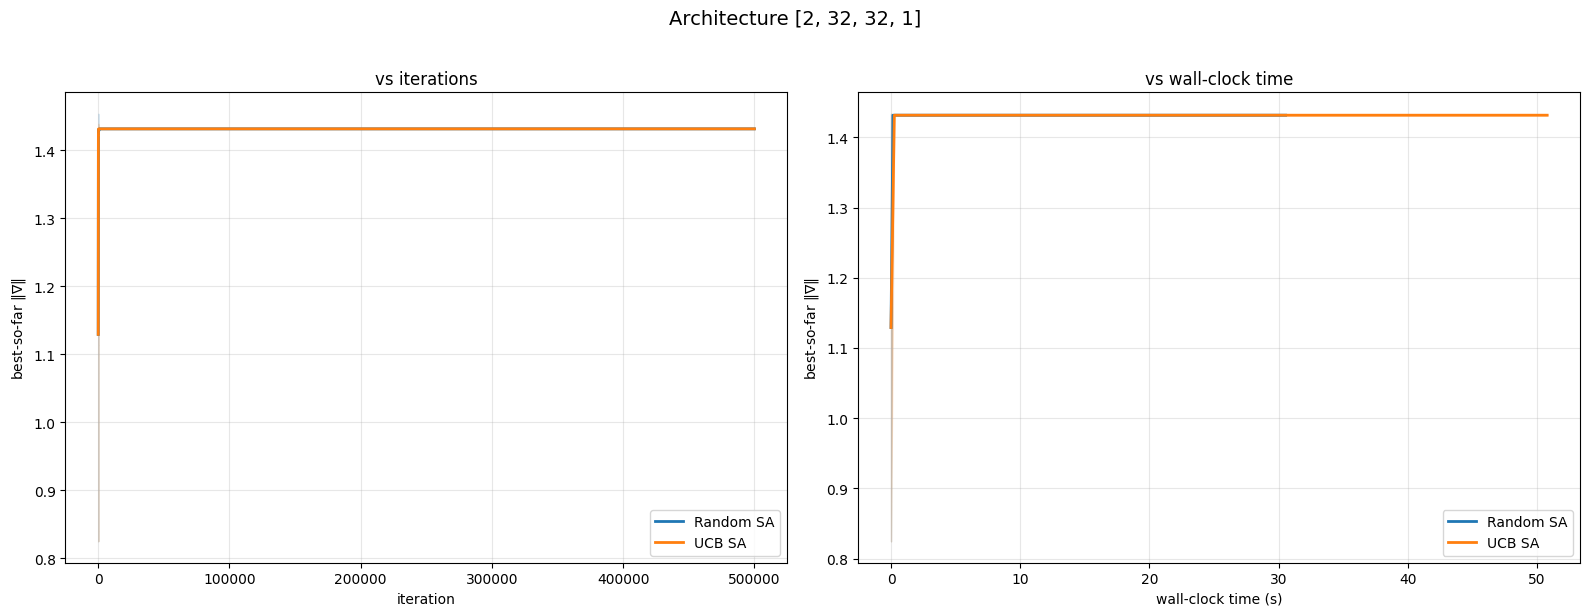

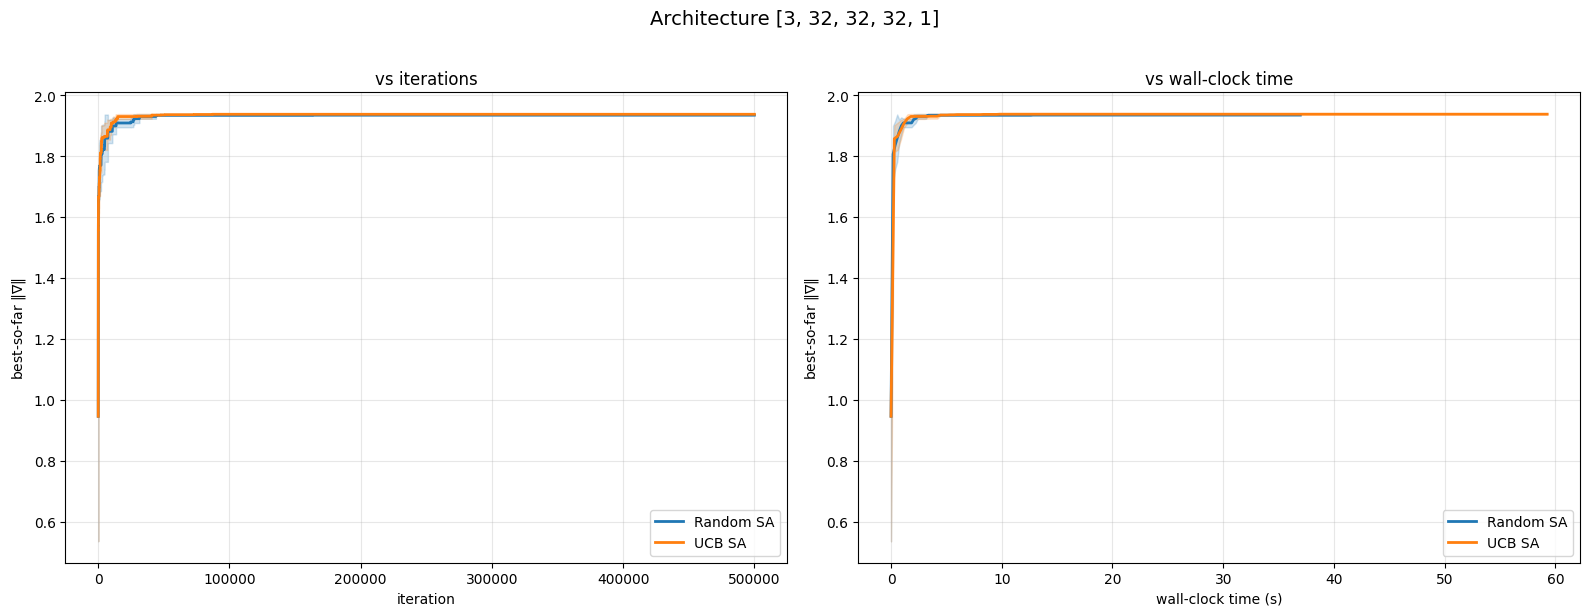

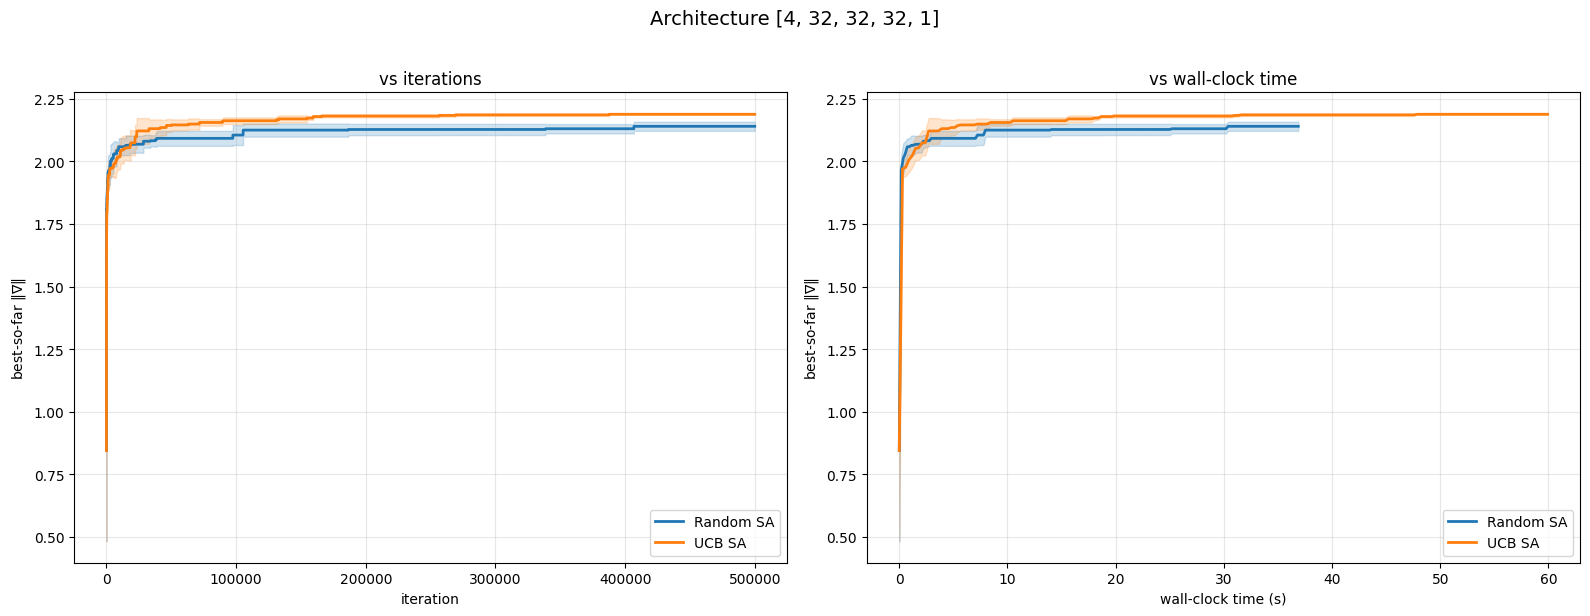

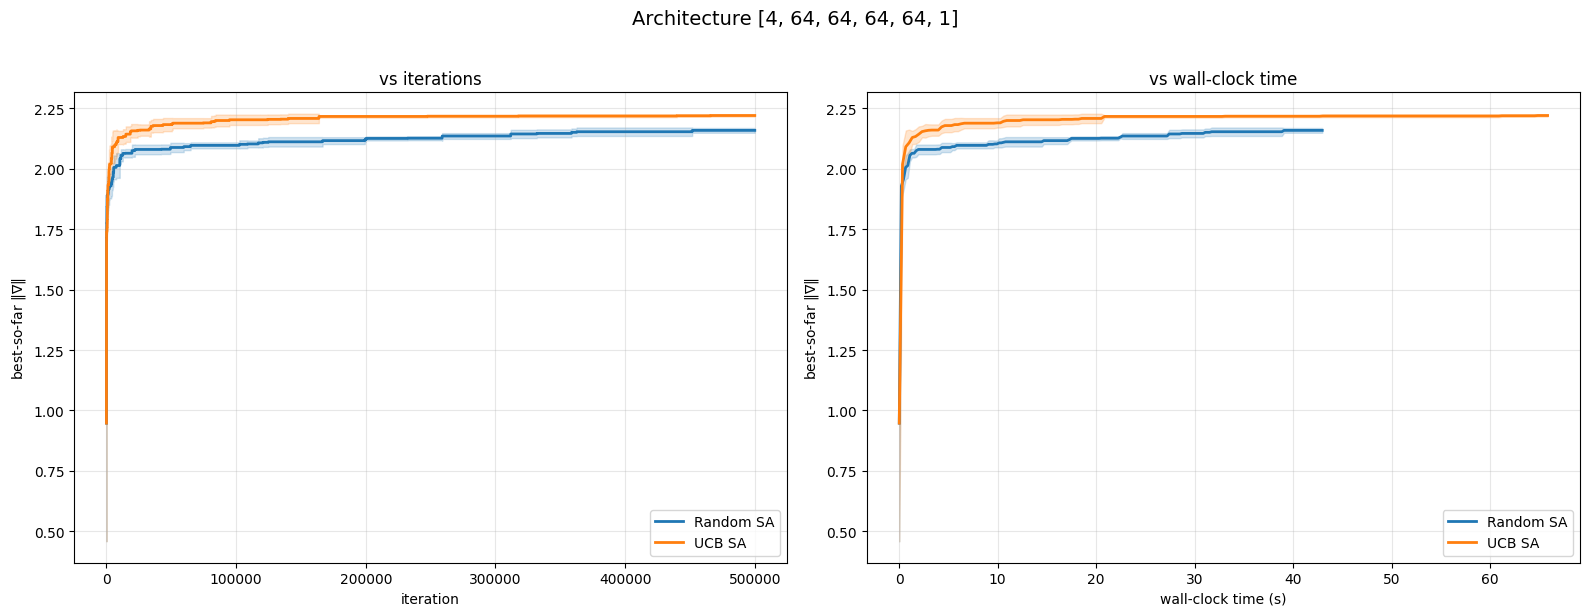

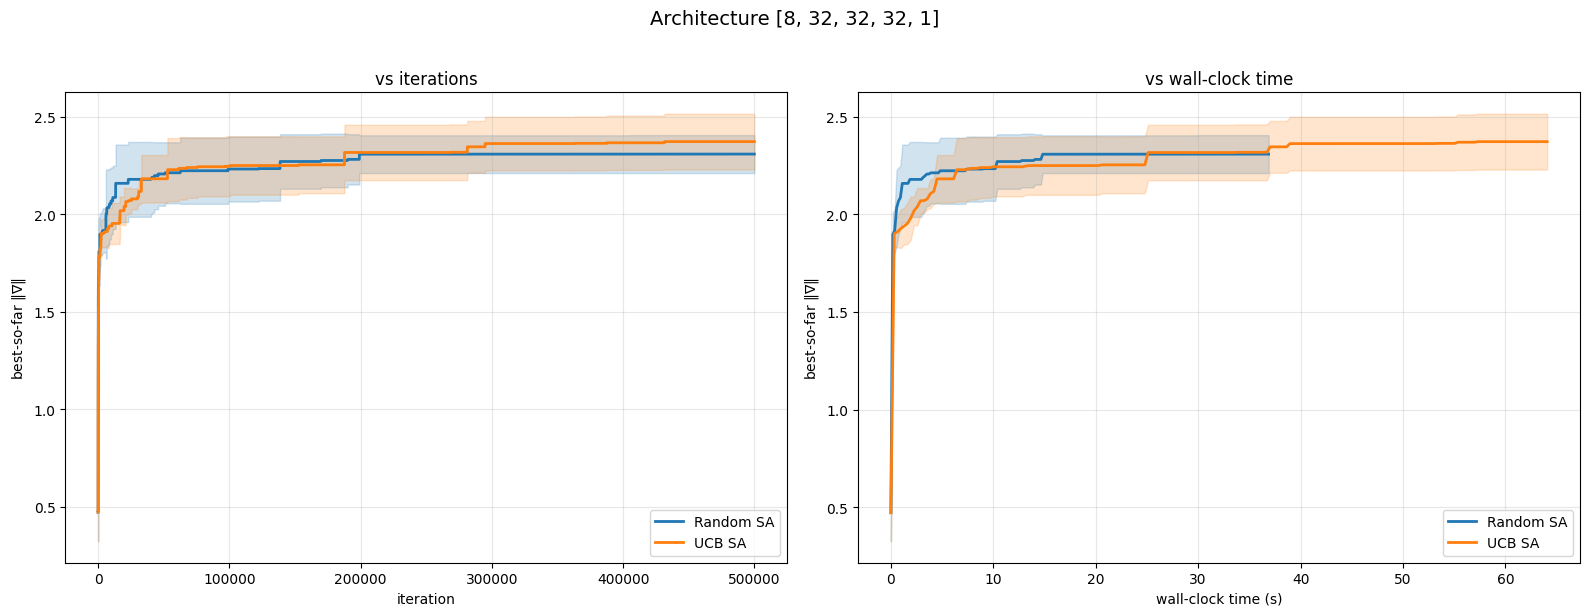

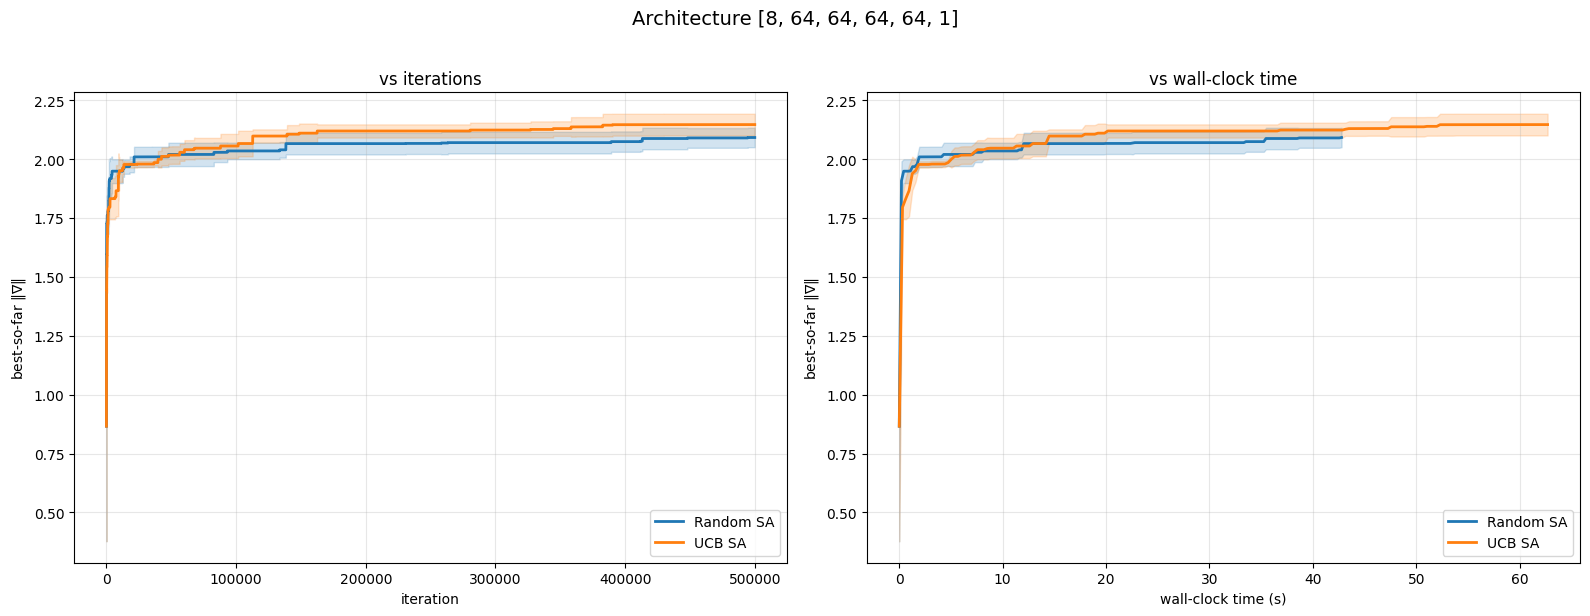

In [5]:
iters = np.arange(1, COMPARE_ITERS + 1)

for arch in ARCHITECTURES:
    r = results[tuple(arch)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Architecture {arch}', fontsize=14, y=1.02)

    # --- vs iterations ---
    ax = axes[0]
    for label, key, color in [('Random SA', 'rand', 'tab:blue'), ('UCB SA', 'ucb', 'tab:orange')]:
        m, s = r[key]['iter_mean'], r[key]['iter_std']
        ax.plot(iters, m, label=label, color=color, linewidth=2)
        ax.fill_between(iters, m - s, m + s, color=color, alpha=0.2)
    ax.set_xlabel('iteration')
    ax.set_ylabel(r'best-so-far $\|\nabla\|$')
    ax.set_title('vs iterations')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    # --- vs wall-clock time ---
    ax = axes[1]
    for label, key, color in [('Random SA', 'rand', 'tab:blue'), ('UCB SA', 'ucb', 'tab:orange')]:
        g, m, s = r[key]['time_grid'], r[key]['time_mean'], r[key]['time_std']
        ax.plot(g, m, label=label, color=color, linewidth=2)
        ax.fill_between(g, m - s, m + s, color=color, alpha=0.2)
    ax.set_xlabel('wall-clock time (s)')
    ax.set_ylabel(r'best-so-far $\|\nabla\|$')
    ax.set_title('vs wall-clock time')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Summary table

In [6]:
def fmt_meanstd(arr, unit='', precision=4):
    s = f"{arr.mean():.{precision}f} ± {arr.std():.{precision}f}{unit}"
    return s


header = (f"{'arch':<22} {'method':>8} "
          f"{'final value':>22} {'total time':>20}")
print(header); print('-' * len(header))

for arch in ARCHITECTURES:
    r = results[tuple(arch)]
    for method, label in [('rand', 'random'), ('ucb', 'ucb')]:
        finals = np.array([h[-1] for h in r[method]['v_hist']])
        times  = np.array([t[-1] for t in r[method]['t_hist']])
        prefix_arch = str(arch) if method == 'rand' else ''
        print(f"{prefix_arch:<22} {label:>8} "
              f"{fmt_meanstd(finals, '', 4):>22} "
              f"{fmt_meanstd(times, ' s', 2):>20}")

arch                     method            final value           total time
---------------------------------------------------------------------------
[2, 32, 32, 1]           random        1.4315 ± 0.0000       31.51 ± 0.57 s
                            ucb        1.4315 ± 0.0000       51.90 ± 0.65 s
[3, 32, 32, 32, 1]       random        1.9343 ± 0.0014       37.76 ± 0.67 s
                            ucb        1.9370 ± 0.0000       61.62 ± 1.75 s
[4, 32, 32, 32, 1]       random        2.1398 ± 0.0182       37.01 ± 0.12 s
                            ucb        2.1879 ± 0.0000       61.76 ± 1.04 s
[4, 64, 64, 64, 64, 1]   random        2.1590 ± 0.0099       43.27 ± 0.26 s
                            ucb        2.2207 ± 0.0044       69.61 ± 2.40 s
[8, 32, 32, 32, 1]       random        2.3082 ± 0.0972       36.97 ± 0.05 s
                            ucb        2.3721 ± 0.1430       68.94 ± 3.54 s
[8, 64, 64, 64, 64, 1]   random        2.0916 ± 0.0412       43.11 ± 0.20 s
            